# This Notebook downloads Gaia data and excludes sources as defined in the Methods. This leaves stars in Gaia with accurate astrometry in the LMC which could potentially be runaways.

The purpose of this file: query Gaia around SN1987A, apply the same Gaia-quality and LMC-membership cuts, and save a clean candidate table.

# Expected runtime: 5-15 minutes on an average Desktop / Laptop

In [33]:
import sys
print(sys.executable)

C:\Users\bukow\anaconda3\envs\mygaia_win_min\python.exe


In [34]:
import sys
import subprocess

print(sys.executable)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "gaiadr3-zeropoint"
])

C:\Users\bukow\anaconda3\envs\mygaia_win_min\python.exe


0

In [35]:
from zero_point import zpt
zpt.load_tables()
print("works")

works


diagnostic cell to see which import is slow:

In [36]:
import time
import importlib

modules = [
    "numpy",
    "pandas",
    "matplotlib.pyplot",
    "os",
    "astroquery.gaia",
    "astropy",
    "astroquery",
    "zero_point.zpt",
    "input_files.Gaia_DR3_filtering",
    "input_files.Gaia_DR3_filtering_nozeropoint",
]

for module in modules:
    t0 = time.perf_counter()
    try:
        importlib.import_module(module)
        print(f"{module:45s} ok   {time.perf_counter() - t0:.2f} s")
    except Exception as e:
        print(f"{module:45s} FAIL {time.perf_counter() - t0:.2f} s")
        print(type(e).__name__, e)

numpy                                         ok   0.00 s
pandas                                        ok   0.00 s
matplotlib.pyplot                             ok   0.00 s
os                                            ok   0.00 s
astroquery.gaia                               ok   0.00 s
astropy                                       ok   0.00 s
astroquery                                    ok   0.00 s
zero_point.zpt                                ok   0.00 s
input_files.Gaia_DR3_filtering                ok   0.00 s
input_files.Gaia_DR3_filtering_nozeropoint    ok   0.00 s


In [37]:
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import os

from input_files import Gaia_DR3_filtering as gdf
from input_files import Gaia_DR3_filtering_nozeropoint as gdf_nozp
from astroquery.gaia import Gaia

print("all imports ok")
%matplotlib inline

all imports ok


# File directory

In [38]:
from pathlib import Path

output_dir = Path("output_files")
input_files_dir = Path("input_files")

output_dir.mkdir(exist_ok=True)
input_files_dir.mkdir(exist_ok=True)

ra_87a = 83.86661833333333
dec_87a = -69.26975372222222

radius_deg = 0.10   # first run: about 86 pc
g_limit = 19.0      # use 18.0 if you want to stay closer to Stoop

In [39]:
parm_circle = [279.4650108, -31.6718983, 2.0]

### Own debugging attempts

In [40]:
from pathlib import Path

raw_file = Path(input_files_dir) / "R136_runaways_raw.csv"

print(raw_file.exists())
if raw_file.exists():
    print(raw_file.resolve())
    print(raw_file.stat().st_size / 1e6, "MB")

False


# Download Gaia data
# This may take 10 minutes

Gaia download. It is like the Stoop query, but centered on SN1987A and using an ICRS circle instead of a Galactic l/b rectangle:

In [41]:
from astroquery.gaia import Gaia

raw_file = input_files_dir / "SN1987A_raw.csv"

tot_string = f"""
SELECT
    *,
    tmass.j_m,
    tmass.j_msigcom,
    tmass.h_m,
    tmass.h_msigcom,
    tmass.ks_m,
    tmass.ks_msigcom
FROM gaiadr3.gaia_source AS dr3
LEFT JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    USING (source_id)
LEFT JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
    USING (clean_tmass_psc_xsc_oid)
LEFT JOIN gaiadr1.tmass_original_valid AS tmass
    ON xjoin.original_psc_source_id = tmass.designation
WHERE 1 = CONTAINS(
    POINT('ICRS', dr3.ra, dr3.dec),
    CIRCLE('ICRS', {ra_87a}, {dec_87a}, {radius_deg})
)
AND dr3.phot_g_mean_mag < {g_limit}
"""

if raw_file.exists():
    print("Raw file already exists:", raw_file)
else:
    job = Gaia.launch_job_async(
        tot_string,
        dump_to_file=True,
        output_format="csv",
        output_file=str(raw_file)
    )

Raw file already exists: input_files\SN1987A_raw.csv


In [42]:
runaways_raw = ps.read_csv(input_files_dir / "SN1987A_raw.csv", low_memory=False)
runaways_all = runaways_raw.copy()

### Own debugging code part 2

In [43]:
print(runaways_raw.shape)
runaways_raw.head()

(3985, 182)


,solution_id,designation,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,...,ks_m,ks_msigcom,ext_key,j_date,j_m.1,j_msigcom.1,h_m.1,h_msigcom.1,ks_m.1,ks_msigcom.1
0,1636148068921376768,Gaia DR3 4657661551726818944,1684570545,2016.0,83.960676,0.064525,-69.358426,0.063207,-0.053759,0.062883,...,15.099,0.163,NaN,2.451581e+06,15.608,0.077,14.965,0.085,15.099,0.163
1,1636148068921376768,Gaia DR3 4657662719957602560,1568073071,2016.0,83.743936,0.024005,-69.314335,0.026007,-0.019278,0.023404,...,15.209,0.176,NaN,2.451581e+06,15.100,0.059,15.122,0.099,15.209,0.176
2,1636148068921376768,Gaia DR3 4657667702122253696,1345182201,2016.0,83.924154,0.111663,-69.295884,0.108513,0.176767,0.103508,...,16.618,NaN,NaN,2.451581e+06,16.460,0.150,15.800,0.194,16.618,NaN
3,1636148068921376768,Gaia DR3 4657662990506729600,407638120,2016.0,83.633646,0.084772,-69.280662,0.099378,-0.099474,0.084868,...,15.345,0.195,NaN,2.451581e+06,16.102,0.116,15.291,0.130,15.345,0.195
4,1636148068921376768,Gaia DR3 4657662372030263808,863616420,2016.0,83.692189,0.106285,-69.342926,0.114768,0.109096,0.102239,...,15.231,0.186,NaN,2.451581e+06,15.743,0.070,15.129,0.086,15.231,0.186


Alternative for the runaways_raw runaways_all cell: This tells pandas to inspect the file more consistently before deciding column types. It will use more memory, but with a 644 MB file that is expected.

In [30]:
runaways_raw = ps.read_csv(
    input_files_dir + 'SN1987A_raw.csv',
    low_memory=False
)

runaways_all = runaways_raw.copy()

TypeError: unsupported operand type(s) for +: 'WindowsPath' and 'str'

To find which column caused it:

In [28]:
cols = ps.read_csv(input_files_dir + 'SN1987A_raw.csv', nrows=1).columns
print(cols[158])

TypeError: unsupported operand type(s) for +: 'WindowsPath' and 'str'

# Galactic coordinates

In [44]:
def icrs_to_gal(ra, ra_error, dec, dec_error, parallax, parallax_error, pmra, pmra_error, pmdec, pmdec_error,
                ra_dec_corr, ra_parallax_corr, ra_pmra_corr, ra_pmdec_corr, dec_parallax_corr, dec_pmra_corr,
                dec_pmdec_corr, parallax_pmra_corr, parallax_pmdec_corr, pmra_pmdec_corr):
    
    A_prime_G = np.array([[-0.0548755604162154, -0.8734370902348850, -0.4838350155487132], [0.4941094278755837, -0.4448296299600112, 0.7469822444972189], [-0.8676661490190047, -0.1980763734312015, 0.4559837761750669]])
    
    # icrs position vector
    r_icrs = np.array([np.cos(np.radians(ra))*np.cos(np.radians(dec)), np.sin(np.radians(ra))*np.cos(np.radians(dec)), np.sin(np.radians(dec))])
    
    # galactic position vector
    r_gal_0 = np.sum(A_prime_G[0,:]*r_icrs)
    r_gal_1 = np.sum(A_prime_G[1,:]*r_icrs)
    r_gal_2 = np.sum(A_prime_G[2,:]*r_icrs)
                      
    # calculate galactic l and b
    l = np.degrees(np.arctan2(r_gal_1, r_gal_0))
    b = np.degrees(np.arctan2(r_gal_2, np.sqrt(r_gal_0**2 + r_gal_1**2)))
    
    p_icrs = np.array([-np.sin(np.radians(ra)), np.cos(np.radians(ra)), 0.])
    q_icrs = np.array([-np.cos(np.radians(ra))*np.sin(np.radians(dec)), -np.sin(np.radians(ra))*np.sin(np.radians(dec)), np.cos(np.radians(dec))])
    
    p_gal = np.array([-np.sin(np.radians(l)), np.cos(np.radians(l)), 0.])
    q_gal = np.array([-np.cos(np.radians(l))*np.sin(np.radians(b)), -np.sin(np.radians(l))*np.sin(np.radians(b)), np.cos(np.radians(b))])
    
    pm_icrs = p_icrs*pmra + q_icrs*pmdec
    
    pm_gal_0 = np.sum(A_prime_G[0,:]*pm_icrs)
    pm_gal_1 = np.sum(A_prime_G[1,:]*pm_icrs)
    pm_gal_2 = np.sum(A_prime_G[2,:]*pm_icrs)
    
    # calculate galactic pml and pmb
    pml = p_gal[0]*pm_gal_0 + p_gal[1]*pm_gal_1 + p_gal[2]*pm_gal_2
    pmb = q_gal[0]*pm_gal_0 + q_gal[1]*pm_gal_1 + q_gal[2]*pm_gal_2
    
    matr_icrs = np.array([[p_icrs[0], q_icrs[0]], [p_icrs[1], q_icrs[1]], [p_icrs[2], q_icrs[2]]])
    matr_gal_prime = np.array([[p_gal[0], q_gal[0]], [p_gal[1], q_gal[1]], [p_gal[2], q_gal[2]]]).T
    
    # obtain G, describing ICRS to galactic rotation
    G = np.matmul(matr_gal_prime, np.matmul(A_prime_G, matr_icrs))
    
    # obtain J, the Jacobian of the transformation
    J = np.array([[G[0,0], G[0,1], 0, 0, 0],
                 [G[1,0], G[1,1], 0, 0, 0],
                 [0, 0, 1, 0, 0], 
                 [0, 0, 0, G[0,0], G[0,1]],
                 [0, 0, 0, G[1,0], G[1,1]]])
    
    # ICRS covariance matrix
    C = np.array([[ra_error**2, ra_error*dec_error*ra_dec_corr, ra_error*parallax_error*ra_parallax_corr, ra_error*pmra_error*ra_pmra_corr, ra_error*pmdec_error*ra_pmdec_corr],
                 [dec_error*ra_error*ra_dec_corr, dec_error**2, dec_error*parallax_error*dec_parallax_corr, dec_error*pmra_error*dec_pmra_corr, dec_error*pmdec_error*dec_pmdec_corr],
                 [parallax_error*ra_error*ra_parallax_corr, parallax_error*dec_error*dec_parallax_corr, parallax_error**2, parallax_error*pmra_error*parallax_pmra_corr, parallax_error*pmdec_error*parallax_pmdec_corr],
                 [pmra_error*ra_error*ra_pmra_corr, pmra_error*dec_error*dec_pmra_corr, pmra_error*parallax_error*parallax_pmra_corr, pmra_error**2, pmra_error*pmdec_error*pmra_pmdec_corr],
                 [pmdec_error*ra_error*ra_pmdec_corr, pmdec_error*dec_error*dec_pmdec_corr, pmdec_error*parallax_error*parallax_pmdec_corr, pmdec_error*pmra_error*pmra_pmdec_corr, pmdec_error**2]])
    
    
    C_gal = np.matmul(J, np.matmul(C, J.T))
    
    l_error = np.sqrt(C_gal[0,0])
    b_error = np.sqrt(C_gal[1,1])
    pml_error = np.sqrt(C_gal[3,3])
    pmb_error = np.sqrt(C_gal[4,4])
    l_b_corr = C_gal[0,1]/(l_error*b_error)
    l_parallax_corr = C_gal[0,2]/(l_error*parallax_error)
    l_pml_corr = C_gal[0,3]/(l_error*pml_error)
    l_pmb_corr = C_gal[0,4]/(l_error*pmb_error)
    b_parallax_corr = C_gal[1,2]/(b_error*parallax_error)
    b_pml_corr = C_gal[1,3]/(b_error*pml_error)
    b_pmb_corr = C_gal[1,3]/(b_error*pmb_error)
    parallax_pml_corr = C_gal[2,3]/(parallax_error*pml_error)
    parallax_pmb_corr = C_gal[2,4]/(parallax_error*pmb_error)
    pml_pmb_corr = C_gal[3,4]/(pml_error*pmb_error)
    
    return l, l_error, b, b_error, pml, pml_error, pmb, pmb_error, l_b_corr, l_parallax_corr, l_pml_corr, l_pmb_corr, b_parallax_corr, b_pml_corr, b_pmb_corr, parallax_pml_corr, parallax_pmb_corr, pml_pmb_corr


# Transform Equatorial to Galactic coordinates

In [45]:
runaways_all['n_iter'] = np.arange(len(runaways_all))
print(runaways_all)

              solution_id                   designation  random_index  \
0     1636148068921376768  Gaia DR3 4657661551726818944    1684570545   
1     1636148068921376768  Gaia DR3 4657662719957602560    1568073071   
2     1636148068921376768  Gaia DR3 4657667702122253696    1345182201   
3     1636148068921376768  Gaia DR3 4657662990506729600     407638120   
4     1636148068921376768  Gaia DR3 4657662372030263808     863616420   
...                   ...                           ...           ...   
3980  1636148068921376768  Gaia DR3 4657662784378791680     351728835   
3981  1636148068921376768  Gaia DR3 4657662857397897728     385864391   
3982  1636148068921376768  Gaia DR3 4657668453761455616     320093242   
3983  1636148068921376768  Gaia DR3 4657665223888990080    1117521265   
3984  1636148068921376768  Gaia DR3 4657669793791552896     534415720   

      ref_epoch         ra  ra_error        dec  dec_error  parallax  \
0        2016.0  83.960676  0.064525 -69.358426   0

In [46]:

l_column = np.zeros(len(runaways_all))
l_error_column = np.zeros(len(runaways_all))
b_column = np.zeros(len(runaways_all))
b_error_column = np.zeros(len(runaways_all))
pml_column = np.zeros(len(runaways_all))
pml_error_column = np.zeros(len(runaways_all))
pmb_column = np.zeros(len(runaways_all))
pmb_error_column = np.zeros(len(runaways_all))
l_b_corr_column = np.zeros(len(runaways_all))
l_parallax_corr_column = np.zeros(len(runaways_all))
l_pml_corr_column = np.zeros(len(runaways_all))
l_pmb_corr_column = np.zeros(len(runaways_all))
b_parallax_corr_column = np.zeros(len(runaways_all))
b_pml_corr_column = np.zeros(len(runaways_all))
b_pmb_corr_column = np.zeros(len(runaways_all))
parallax_pml_corr_column = np.zeros(len(runaways_all))
parallax_pmb_corr_column = np.zeros(len(runaways_all))
pml_pmb_corr_column = np.zeros(len(runaways_all))

ii = 0

runaways_all = runaways_all.sort_values('ra')
for index, row in runaways_all.sort_values('ra').iterrows():
    l, l_error, b, b_error, pml, pml_error, pmb, pmb_error, l_b_corr, l_parallax_corr, l_pml_corr, l_pmb_corr, b_parallax_corr, b_pml_corr, b_pmb_corr, parallax_pml_corr, parallax_pmb_corr, pml_pmb_corr = icrs_to_gal(row.ra, row.ra_error, row.dec, row.dec_error, row.parallax, row.parallax_error, row.pmra, row.pmra_error, row.pmdec, row.pmdec_error, row.ra_dec_corr, row.ra_parallax_corr, row.ra_pmra_corr, row.ra_pmdec_corr, row.dec_parallax_corr, row.dec_pmra_corr, row.dec_pmdec_corr, row.parallax_pmra_corr, row.parallax_pmdec_corr, row.pmra_pmdec_corr)
    l_column[ii] = l
    l_error_column[ii] = l_error
    b_column[ii] = b
    b_error_column[ii] = b_error
    pml_column[ii] = pml
    pml_error_column[ii] = pml_error
    pmb_column[ii] = pmb
    pmb_error_column[ii] = pmb_error
    l_b_corr_column[ii] = l_b_corr
    l_parallax_corr_column[ii] = l_parallax_corr
    l_pml_corr_column[ii] = l_pml_corr
    l_pmb_corr_column[ii] = l_pmb_corr
    b_parallax_corr_column[ii] = b_parallax_corr
    b_pml_corr_column[ii] = b_pml_corr
    b_pmb_corr_column[ii] = b_pmb_corr
    parallax_pml_corr_column[ii] = parallax_pml_corr
    parallax_pmb_corr_column[ii] = parallax_pmb_corr
    pml_pmb_corr_column[ii] = pml_pmb_corr
    if ii%1000 == 0:
        print(ii)
    ii+=1

runaways_all['l'] = l_column
runaways_all['l'] = runaways_all.l + 360
runaways_all['l_error'] = l_error_column
runaways_all['b'] = b_column
runaways_all['b_error'] = b_error_column
runaways_all['pml'] = pml_column
runaways_all['pml_error'] = pml_error_column
runaways_all['pmb'] = pmb_column
runaways_all['pmb_error'] = pmb_error_column
runaways_all['l_b_corr'] = l_b_corr_column
runaways_all['l_parallax_corr'] = l_parallax_corr_column
runaways_all['l_pml_corr'] = l_pml_corr_column
runaways_all['l_pmb_corr'] = l_pmb_corr_column
runaways_all['b_parallax_corr'] = b_parallax_corr_column
runaways_all['b_pml_corr'] = b_pml_corr_column
runaways_all['b_pmb_corr'] = b_pmb_corr_column
runaways_all['parallax_pml_corr'] = parallax_pml_corr_column
runaways_all['parallax_pmb_corr'] = parallax_pmb_corr_column
runaways_all['pml_pmb_corr'] = pml_pmb_corr_column




0
1000
2000
3000




# Apply the Gaia zero point offset

In [47]:
print(len(runaways_all))
runaways_all = gdf.gaia_filtering(runaways_all, 1e10, 1e10, -1e10, 1e10, 1e10)
print(len(runaways_all))

3985
After excluding on ruwe: 3985 sources left
After excluding on ipd_frac_multi_peak: 3985 sources left
After excluding on visibility_periods_used: 3985 sources left
After excluding on duplicated_source: 3985 sources left
After excluding on ipd_gof_harmonic_amplitude: 3985 sources left
3985


C:\Users\bukow\anaconda3\envs\mygaia_win_min\Lib\site-packages\zero_point\zpt.py:233: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


^ ot an error. It is a warning from the Gaia parallax zero-point correction package. the function completed. Nothing crashed.

The warnings mean: for some Gaia sources, the values used to compute the parallax zero-point correction are outside the calibrated range of the zero_point package: These warnings are common when applying Gaia zero-point corrections to a large raw catalogue. The Stoop et al. method does correct the Gaia parallax zero-point and then applies Gaia-quality / LMC membership filters, so this warning is happening in the expected part of the workflow.

The reason no sources were removed is because this call uses deliberately huge limits: Those thresholds are basically “do not actually filter yet.” It is probably just applying zero-point correction and checking the filter machinery.

# Runaway Gaia parameters

In [48]:
import astropy.units as u
from astropy.coordinates import SkyCoord

r_search = 1.0  # deg; broad test region

sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
coords = SkyCoord(
    ra=runaways_all["ra"].values * u.deg,
    dec=runaways_all["dec"].values * u.deg,
    frame="icrs"
)

sep = sn87a.separation(coords).deg

runaways_raw = runaways_all.copy()
runaways_raw = runaways_raw[sep < r_search].copy()

print(len(runaways_raw))

3985


In [49]:
import astropy.units as u
from astropy.coordinates import SkyCoord

# SN1987A position, ICRS
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")

center_l = sn87a.galactic.l.deg
center_b = sn87a.galactic.b.deg

r_search = 0.10  # or 0.25 / 0.50 / 1.0, depending on the run

# Compatibility with old R136 code
parm_circle = [center_l, center_b, r_search]

print("SN1987A galactic centre:", parm_circle)

SN1987A galactic centre: [np.float64(279.7034482944957), np.float64(-31.937110459733457), 0.1]


1.1781839814960426


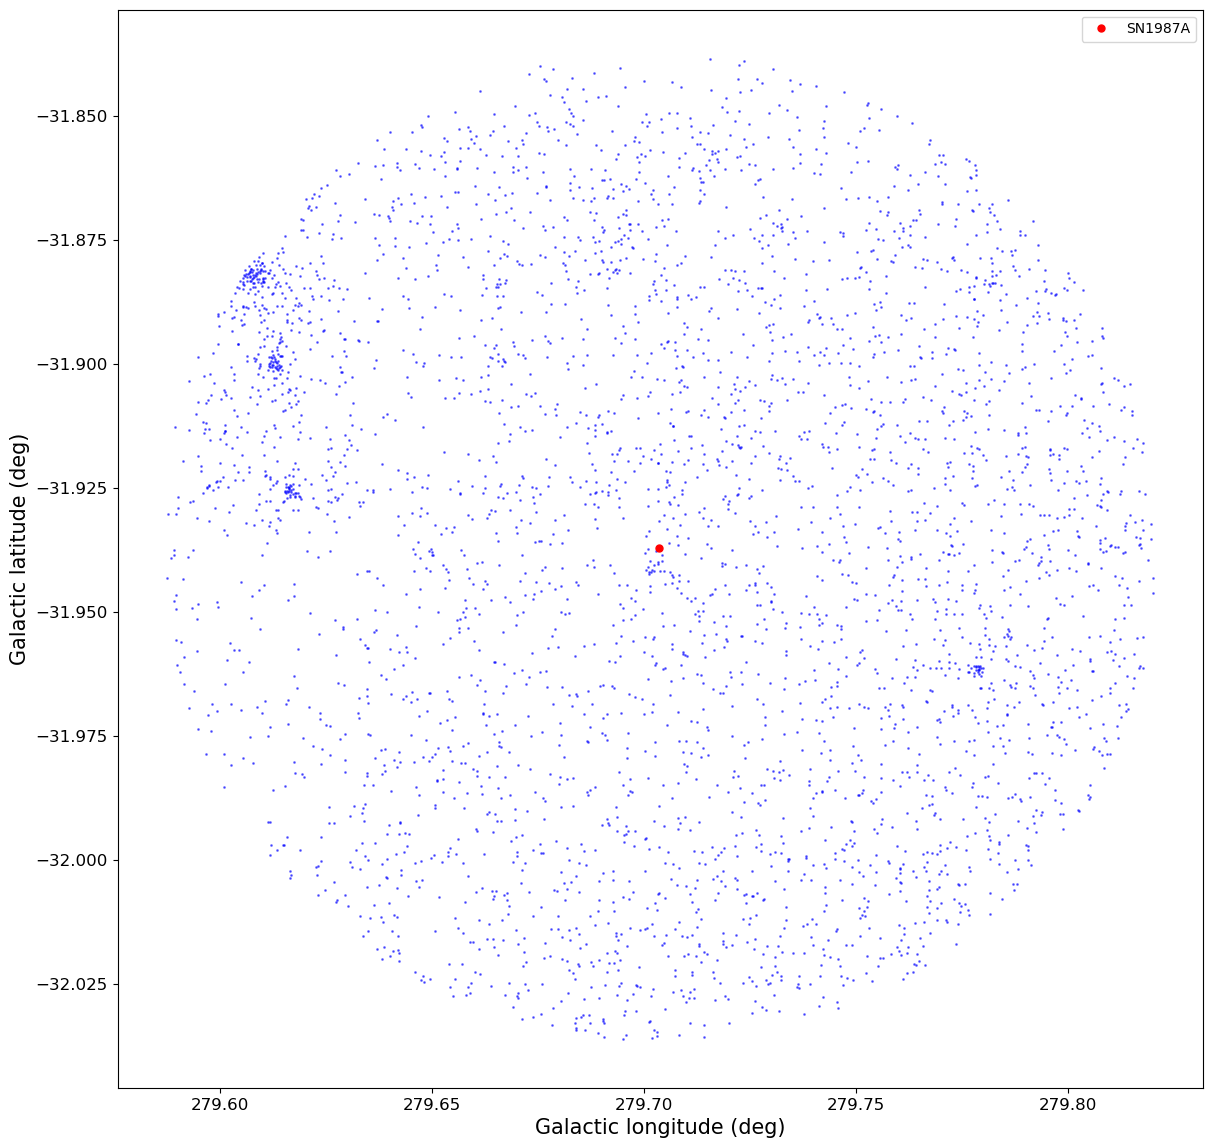

In [50]:
fig, ax = plt.subplots(1, figsize=(14, 14))

print(
    (np.amax(runaways_raw.l) - np.amin(runaways_raw.l)) /
    (np.amax(runaways_raw.b) - np.amin(runaways_raw.b))
)

ax.plot(runaways_raw.l, runaways_raw.b, 'bo', ms=1., alpha=0.5)

# Mark SN1987A
ax.plot(center_l, center_b, 'ro', ms=5., label='SN1987A')

ax.tick_params(labelsize=12)
ax.set_xlabel('Galactic longitude (deg)', fontsize=15)
ax.set_ylabel('Galactic latitude (deg)', fontsize=15)
ax.legend()

plt.show()

In [51]:
from pathlib import Path
import pandas as pd
import numpy as np

# Folders
input_files_dir = Path("input_files")
output_dir = Path("output_files")
output_dir.mkdir(exist_ok=True)

# Load raw Gaia table if it is not already in memory
# Prefer the raw input file. If that does not exist, use the saved zero-point/raw output.
if "runaways_raw" not in globals():
    if (input_files_dir / "SN1987A_raw.csv").exists():
        runaways_raw = pd.read_csv(input_files_dir / "SN1987A_raw.csv", low_memory=False)
        print("Loaded:", input_files_dir / "SN1987A_raw.csv")
    elif (output_dir / "SN1987A_raw_zp.csv").exists():
        runaways_raw = pd.read_csv(output_dir / "SN1987A_raw_zp.csv", low_memory=False)
        print("Loaded:", output_dir / "SN1987A_raw_zp.csv")
    else:
        raise FileNotFoundError("Could not find SN1987A_raw.csv or SN1987A_raw_zp.csv")

# Make sure column names are clean
runaways_raw.columns = runaways_raw.columns.str.strip()

# Gaia quality-cut parameters
max_ruwe = 1.4
max_ipd_frac_multi_peak = 10.0
min_visibility_periods_used = 10
max_duplicated_source = 0.5
max_ipd_gof_harmonic_amplitude = 0.15

print("Raw Gaia rows:", len(runaways_raw))
print("Quality-cut parameters defined.")

Raw Gaia rows: 3985
Quality-cut parameters defined.


In [52]:
runaways_filter = runaways_raw.copy()
runaways = gdf_nozp.gaia_filtering(runaways_filter, max_ruwe, max_ipd_frac_multi_peak, min_visibility_periods_used, 
                              max_duplicated_source, max_ipd_gof_harmonic_amplitude)


After excluding on ruwe: 3515 sources left
After excluding on ipd_frac_multi_peak: 3363 sources left
After excluding on visibility_periods_used: 3333 sources left
After excluding on duplicated_source: 3326 sources left
After excluding on ipd_gof_harmonic_amplitude: 3314 sources left


# Filter on parallax

In [53]:
print(len(runaways))
runaways = runaways[runaways.parallax_error < 0.05]
runaways = runaways[runaways.parallax - 3*runaways.parallax_error < 1/49.59]
print(len(runaways))

3314
481


# Selection summary and candidate table

In [54]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame

# ------------------------------------------------------------
# Selection summary and candidate table 
# ------------------------------------------------------------

# Constants
D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000
masyr_to_kms = 4.74047 * D_LMC_kpc

# SN1987A position and proper motion
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
pmra_87a = 1.60
pmdec_87a = 0.44

# copies so the table is reproducible
raw_sample = runaways_raw.copy()
clean_sample = runaways.copy()

def add_sn1987a_columns(table):
    """
    Add projected separation from SN1987A and velocity difference
    from the adopted SN1987A proper motion.
    """
    table = table.copy()
    table.columns = table.columns.str.strip()

    coords = SkyCoord(
        ra=table["ra"].values * u.deg,
        dec=table["dec"].values * u.deg,
        frame="icrs"
    )

    frame_87a = SkyOffsetFrame(origin=sn87a)
    offsets = coords.transform_to(frame_87a)

    table["x_pc"] = offsets.lon.to_value(u.rad) * D_LMC_pc
    table["y_pc"] = offsets.lat.to_value(u.rad) * D_LMC_pc
    table["sep_87a_pc"] = np.sqrt(table["x_pc"]**2 + table["y_pc"]**2)

    table["dpm_abs_87a_masyr"] = np.hypot(
        table["pmra"] - pmra_87a,
        table["pmdec"] - pmdec_87a
    )

    table["dv_abs_87a_kms"] = masyr_to_kms * table["dpm_abs_87a_masyr"]

    return table

raw_sample = add_sn1987a_columns(raw_sample)
clean_sample = add_sn1987a_columns(clean_sample)

# Local LMC median, estimated from the cleaned sample within 100 pc
local_for_median = clean_sample[clean_sample["sep_87a_pc"] < 100].copy()

if len(local_for_median) < 20:
    local_for_median = clean_sample.copy()

pmra_local = np.nanmedian(local_for_median["pmra"])
pmdec_local = np.nanmedian(local_for_median["pmdec"])

clean_sample["dpm_vs_local_masyr"] = np.hypot(
    clean_sample["pmra"] - pmra_local,
    clean_sample["pmdec"] - pmdec_local
)
clean_sample["dv_vs_local_kms"] = masyr_to_kms * clean_sample["dpm_vs_local_masyr"]

print("Local median PMRA*:", pmra_local)
print("Local median PMDec:", pmdec_local)

# ------------------------------------------------------------
# Defining selections
# ------------------------------------------------------------

within_100pc = clean_sample["sep_87a_pc"] < 100
within_30pc = clean_sample["sep_87a_pc"] < 30

comoving_100pc_30kms = (
        (clean_sample["sep_87a_pc"] < 100) &
        (clean_sample["dv_abs_87a_kms"] < 30)
)

comoving_30pc_20kms = (
        (clean_sample["sep_87a_pc"] < 30) &
        (clean_sample["dv_abs_87a_kms"] < 20)
)

high_residual_50kms = clean_sample["dv_abs_87a_kms"] > 50

# ------------------------------------------------------------
# Cut summary table
# ------------------------------------------------------------

cut_summary = pd.DataFrame([
    {
        "selection": "all Gaia sources after query",
        "n_stars": len(raw_sample)
    },
    {
        "selection": "after Gaia quality + parallax cuts",
        "n_stars": len(clean_sample)
    },
    {
        "selection": "within 100 pc of SN1987A",
        "n_stars": int(within_100pc.sum())
    },
    {
        "selection": "within 30 pc of SN1987A",
        "n_stars": int(within_30pc.sum())
    },
    {
        "selection": "within 100 pc and <30 km/s from SN1987A PM",
        "n_stars": int(comoving_100pc_30kms.sum())
    },
    {
        "selection": "within 30 pc and <20 km/s from SN1987A PM",
        "n_stars": int(comoving_30pc_20kms.sum())
    },
    {
        "selection": ">50 km/s from SN1987A PM",
        "n_stars": int(high_residual_50kms.sum())
    },
])

cut_summary["fraction_of_query"] = cut_summary["n_stars"] / len(raw_sample)

display(cut_summary)

# Save table 
cut_summary.to_csv(output_dir / "SN1987A_cut_summary.csv", index=False)

# 
#  LaTeX version for direct use in thesis
cut_summary_latex = cut_summary.copy()
cut_summary_latex["fraction_of_query"] = cut_summary_latex["fraction_of_query"].map(lambda x: f"{x:.3f}")

cut_summary_latex.to_latex(
    output_dir / "SN1987A_cut_summary.tex",
    index=False,
    caption="Summary of Gaia DR3 selection cuts around SN1987A.",
    label="tab:sn1987a_cut_summary"
)

# ------------------------------------------------------------
# Candidate table
# ------------------------------------------------------------

clean_sample["local_comoving_30pc_20kms"] = comoving_30pc_20kms
clean_sample["local_comoving_100pc_30kms"] = comoving_100pc_30kms
clean_sample["high_residual_50kms"] = high_residual_50kms

clean_sample["candidate_class"] = "other"

clean_sample.loc[
    high_residual_50kms,
    "candidate_class"
] = "high_residual_50kms"

clean_sample.loc[
    comoving_100pc_30kms,
    "candidate_class"
] = "local_comoving_100pc_30kms"

clean_sample.loc[
    comoving_30pc_20kms,
    "candidate_class"
] = "local_comoving_30pc_20kms"

candidate_table = clean_sample[
    comoving_30pc_20kms |
    comoving_100pc_30kms |
    high_residual_50kms
    ].copy()

candidate_columns = [
    "source_id",
    "ra",
    "dec",
    "phot_g_mean_mag",
    "bp_rp",
    "pmra",
    "pmdec",
    "pmra_error",
    "pmdec_error",
    "ruwe",
    "x_pc",
    "y_pc",
    "sep_87a_pc",
    "dpm_abs_87a_masyr",
    "dv_abs_87a_kms",
    "dpm_vs_local_masyr",
    "dv_vs_local_kms",
    "local_comoving_30pc_20kms",
    "local_comoving_100pc_30kms",
    "high_residual_50kms",
    "candidate_class",
]

candidate_columns = [col for col in candidate_columns if col in candidate_table.columns]

candidate_table = candidate_table[candidate_columns].sort_values(
    by=["candidate_class", "sep_87a_pc", "dv_abs_87a_kms"]
)

display(candidate_table.head(20))

candidate_table.to_csv(output_dir / "SN1987A_candidate_table.csv", index=False)

# full table with cleaned plots, perchance useful in the futute
clean_sample.to_csv(output_dir / "SN1987A_cands_with_selection_flags.csv", index=False)

print("Saved:")
print(output_dir / "SN1987A_cut_summary.csv")
print(output_dir / "SN1987A_cut_summary.tex")
print(output_dir / "SN1987A_candidate_table.csv")
print(output_dir / "SN1987A_cands_with_selection_flags.csv")

Local median PMRA*: 1.6620673041034726
Local median PMDec: 0.5548392282938217


,selection,n_stars,fraction_of_query
0,all Gaia sources after query,3985,1.000000
1,after Gaia quality + parallax cuts,481,0.120703
2,within 100 pc of SN1987A,481,0.120703
3,within 30 pc of SN1987A,59,0.014806
4,within 100 pc and <30 km/s from SN1987A PM,135,0.033877
5,within 30 pc and <20 km/s from SN1987A PM,3,0.000753
6,>50 km/s from SN1987A PM,169,0.042409


,source_id,ra,dec,phot_g_mean_mag,bp_rp,pmra,pmdec,pmra_error,pmdec_error,ruwe,...,y_pc,sep_87a_pc,dpm_abs_87a_masyr,dv_abs_87a_kms,dpm_vs_local_masyr,dv_vs_local_kms,local_comoving_30pc_20kms,local_comoving_100pc_30kms,high_residual_50kms,candidate_class
385,4657668007030021248,83.867773,-69.269970,15.773073,0.251451,1.324677,0.589892,0.049405,0.043152,1.142589,...,-0.186804,0.399957,0.313481,73.693194,0.339207,79.740692,False,False,True,high_residual_50kms
504,4657668075746867584,83.853870,-69.268200,15.859596,-0.101064,1.453357,0.609643,0.050541,0.047101,0.987554,...,1.344500,4.130746,0.224239,52.713984,0.215786,50.726932,False,False,True,high_residual_50kms
309,4657668080079330048,83.835070,-69.261018,16.920755,1.722948,2.109048,0.635898,0.080630,0.069402,0.957565,...,7.558127,12.272698,0.545441,128.222260,0.454271,106.790046,False,False,True,high_residual_50kms
316,4657667942640388352,83.826788,-69.275180,13.216023,1.933559,1.652132,0.651707,0.018281,0.016824,1.105382,...,-4.700627,13.073836,0.218032,51.254845,0.097376,22.891245,False,False,True,high_residual_50kms
125,4657668045719599744,83.896270,-69.258120,16.284328,1.874653,1.840797,0.514940,0.054852,0.047745,1.022528,...,10.067059,13.562968,0.252189,59.284504,0.183129,43.049923,False,False,True,high_residual_50kms
959,4657668041387134592,83.902849,-69.259996,16.401098,2.028217,1.621117,0.675965,0.057392,0.051177,0.985876,...,8.442514,13.949506,0.236908,55.692291,0.127861,30.057521,False,False,True,high_residual_50kms
45,4657668045719588608,83.876217,-69.250723,16.784159,1.922768,1.650464,0.884640,0.072090,0.062053,1.025287,...,16.470705,16.731610,0.447494,105.196956,0.330005,77.577484,False,False,True,high_residual_50kms
318,4657668732914362368,83.811435,-69.269888,15.732141,2.337147,1.800101,0.580553,0.045332,0.041316,1.099151,...,-0.123508,16.906342,0.244531,57.484365,0.140408,33.007108,False,False,True,high_residual_50kms
1178,4657668045719603840,83.914978,-69.259098,15.858542,1.510490,1.652687,1.029023,0.042359,0.036601,0.988777,...,9.216441,17.454629,0.591375,139.020304,0.474277,111.492881,False,False,True,high_residual_50kms
3095,4657667873920931456,83.868477,-69.289949,16.375343,-0.160824,1.780470,0.574806,0.058847,0.049261,1.001431,...,-17.478875,17.488131,0.225260,52.954100,0.120074,28.227091,False,False,True,high_residual_50kms


Saved:
output_files\SN1987A_cut_summary.csv
output_files\SN1987A_cut_summary.tex
output_files\SN1987A_candidate_table.csv
output_files\SN1987A_cands_with_selection_flags.csv


# Save the runaway candidates

In [ ]:
runaways.to_csv(output_dir / "SN1987A_cands.csv", index=False)
runaways_raw.to_csv(output_dir / "SN1987A_raw_zp.csv", index=False)

finished the first stage: generating / filtering the Gaia catalogue used as input for the runaway search; checking what files the notebook created or updated:

In [ ]:
from pathlib import Path
import pandas as pd

for folder in ["input_files", "output_files"]:
    print("\n" + folder)
    for f in sorted(Path(folder).glob("*.csv")):
        print(f"{f.name:35s} {f.stat().st_size/1e6:8.2f} MB")

inspecting the main output tables

In [ ]:
for fname in [
    "input_files/R136_runaways_raw.csv",
    "output_files/runaways_cands.csv",
    "output_files/runaways_mcmc.csv",
    "output_files/runaways_outliers_mcmc.csv",
    "output_files/runaways_raw_zp_1deg.csv",
]:
    f = Path(fname)
    if f.exists():
        df = pd.read_csv(f, nrows=5)
        print("\n", fname)
        print("columns:", list(df.columns[:15]), "...")
        print(df.head())

cleaner overview:

In [ ]:
from pathlib import Path
import pandas as pd

for fname in [
    "output_files/runaways_raw_zp_1deg.csv",
    "output_files/runaways_cands.csv",
    "output_files/runaways_mcmc.csv",
    "output_files/runaways_outliers_mcmc.csv",
]:
    f = Path(fname)
    if f.exists():
        df = pd.read_csv(f)
        print(fname)
        print("shape:", df.shape)
        print("first columns:", list(df.columns[:20]))
        print()

In [ ]:
cands_file = output_dir / "SN1987A_cands.csv"

if not cands_file.exists():
    raise FileNotFoundError(
        "Missing output_files/SN1987A_cands.csv. "
        "First run the cleaned Gaia-candidate notebook."
    )

df = pd.read_csv(cands_file, low_memory=False)
df.columns = df.columns.str.strip()

coords = SkyCoord(df["ra"].values*u.deg, df["dec"].values*u.deg, frame="icrs")
sep_deg = sn87a.separation(coords).deg
sep_pc = sn87a.separation(coords).radian * D_LMC_KPC * 1000.0

df["sep_87a_deg"] = sep_deg
df["sep_87a_pc"] = sep_pc

print("Rows:", len(df))
print("Max separation from SN1987A [deg]:", np.nanmax(df["sep_87a_deg"]))
print("Max separation from SN1987A [pc]:", np.nanmax(df["sep_87a_pc"]))
print("Median RA/Dec:", np.nanmedian(df["ra"]), np.nanmedian(df["dec"]))

# For the 0.10 deg run, max separation should be about 0.10 deg.
# Leave tolerance because later you may intentionally run 0.25 or 0.50 deg.
if np.nanmax(df["sep_87a_deg"]) > 0.55:
    raise ValueError(
        "This candidate file is too wide for the current SN1987A runs. "
        "It may be an R136/raw file or a 1-2 degree test file. "
        "Regenerate SN1987A_cands.csv from SN1987A_raw.csv."
    )

df.to_csv(output_dir / "SN1987A_cands_checked.csv", index=False)
df.head()


raw Gaia query

has proper motions

RUWE < 1.4

visibility_periods_used >= 10

not duplicated_source

IPD cuts passed

parallax consistent with LMC / not foreground

within 100 pc of SN1987A

within 50 pc of SN1987A

dv_local_resid < 30 km/s

dv_local_resid < 20 km/s

In [1]:
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["dv_local_resid_kms"],
    vmin=0,
    vmax=80,
    s=10,
    alpha=0.6
)

cand = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_local_resid_kms"] < 30)
    ]

ax.scatter(
    cand["bp_rp"],
    cand["phot_g_mean_mag"],
    facecolors="none",
    edgecolors="black",
    s=45,
    label="co-moving candidates"
)

ax.invert_yaxis()
ax.set_xlabel("BP - RP")
ax.set_ylabel("G")
ax.set_title("Gaia CMD near SN1987A coloured by PM difference")
ax.legend()

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Residual velocity difference [km/s]")

NameError: name 'plt' is not defined